## <span style="color:#2F749F;"><strong>📦 Sesión práctica 5: Imputación de datos</strong></span>
---

- Juan Diego Muñetón Herrera

- Robert Alexander Blandón Rincón


## <span style="color:#2F749F;"><strong>Ejercicio 1. Limpieza e imputación de un conjunto de datos mixto</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
        'Edad': [25, np.nan, 35, 29, -5, 25, None],
        'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
        'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
        'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
    })

2. En un nuevo notebook, aplica las etapas del proceso de limpieza e imputación de datos que consideres necesarias sobre el DataFrame df. Ten encuenta incluir:
    - Código correctamente comentado y ejecutado.
    - Explicaciones breves de cada paso.
    - Resultados visuales o estadísticos que evidencien las transformaciones.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer


In [2]:
df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'Pedro', None, 'Marta', 'Luis', 'Sofía'],
    'Edad': [25, np.nan, 35, 29, -5, 25, None],
    'Ciudad': ['Bogotá', 'Medellín', None, 'Medellín', 'Cali', 'Bogotá', 'Cali'],
    'Ingreso': [3500, 4800, np.nan, 5200, 5100, np.nan, 4700],
    'FechaIngreso': ['2023-01-01', '2023-01-05', None, '2023-01-10', '2023-01-12', None, '2023-01-15']
})

In [3]:
#Copia del dataframe
df_original = df.copy()

## <span style="color:#2F749F;"><strong>Exploración inicial</strong></span>


Esta exploración permitirá identificar valores nulos, detectar errores y revisamos tipos de datos.

In [4]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Nombre        6 non-null      object 
 1   Edad          5 non-null      float64
 2   Ciudad        6 non-null      object 
 3   Ingreso       5 non-null      float64
 4   FechaIngreso  5 non-null      object 
dtypes: float64(2), object(3)
memory usage: 412.0+ bytes


,Edad,Ingreso
count,5.000000,5.000000
mean,21.800000,4660.000000
std,15.530615,680.441033
min,-5.000000,3500.000000
25%,25.000000,4700.000000
50%,25.000000,4800.000000
75%,29.000000,5100.000000
max,35.000000,5200.000000


## <span style="color:#2F749F;"><strong>Limpieza de datos</strong></span>

In [5]:
#Corregir tipos de datos
df['FechaIngreso'] = pd.to_datetime(df['FechaIngreso'])

#Manejo de valores erróneos
df.loc[df['Edad'] < 0, 'Edad'] = np.nan

#Manejo de valores nulos
df.dropna(subset=['Nombre'], inplace=True)

#Eliminar duplicados
df.drop_duplicates(inplace=True)

#Analizar correlaciones
df.corr(numeric_only=True)

,Edad,Ingreso
Edad,1.0,NaN
Ingreso,NaN,1.0


## <span style="color:#2F749F;"><strong>Imputación de datos</strong></span>

In [6]:
#Variable categórica: Nombre
df['Nombre'].fillna('Desconocido', inplace=True)

#Variable numérica: Edad
df['Edad'].fillna(df['Edad'].mean(), inplace=True)

#Variable categórica: Ciudad
df['Ciudad'].fillna(df['Ciudad'].mode()[0], inplace=True)

#Variable numérica: Ingreso
df['Ingreso'].fillna(df['Ingreso'].median(), inplace=True)

#Variable temporal: FechaIngreso
df['FechaIngreso'].fillna(df['FechaIngreso'].mode()[0], inplace=True)

/tmp/ipykernel_3563/3975937159.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Nombre'].fillna('Desconocido', inplace=True)
/tmp/ipykernel_3563/3975937159.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

## <span style="color:#2F749F;"><strong>Verificación de resultados</strong></span>

In [7]:
#verificar que no existen valores nulos en el dataset.
df.isnull().sum()
df.describe()
df

,Nombre,Edad,Ciudad,Ingreso,FechaIngreso
0,Ana,25.000000,Bogotá,3500.0,2023-01-01
1,Luis,28.333333,Medellín,4800.0,2023-01-05
2,Pedro,35.000000,Bogotá,4750.0,2023-01-01
4,Marta,28.333333,Cali,5100.0,2023-01-12
5,Luis,25.000000,Bogotá,4750.0,2023-01-01
6,Sofía,28.333333,Cali,4700.0,2023-01-15


## <span style="color:#2F749F;"><strong>Resultados visuales o estadísticos que evidencien las transformaciones.</strong></span>

In [8]:
#Comparación de valores nulos

print("Antes de la imputación:\n")
print(df_original.isnull().sum())

print("\nDespués de la imputación:\n")
print(df.isnull().sum())

Antes de la imputación:

Nombre          1
Edad            2
Ciudad          1
Ingreso         2
FechaIngreso    2
dtype: int64

Después de la imputación:

Nombre          0
Edad            0
Ciudad          0
Ingreso         0
FechaIngreso    0
dtype: int64


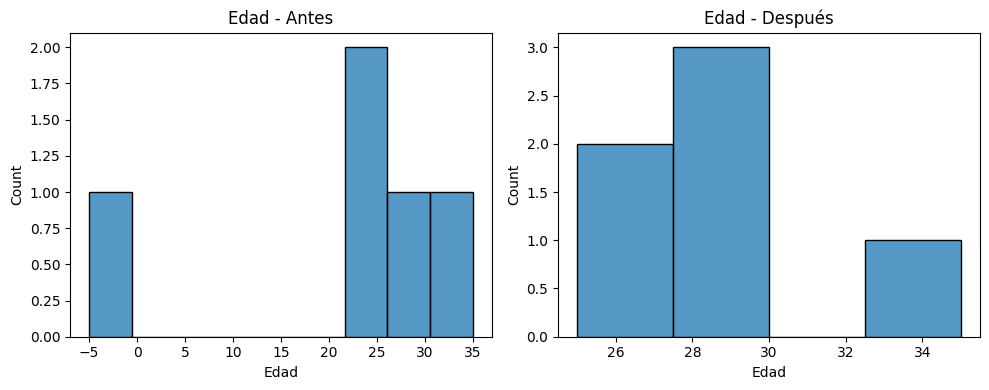

In [9]:
#Comparación de distribuciones
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_original['Edad'], kde=False)
plt.title("Edad - Antes")

plt.subplot(1,2,2)
sns.histplot(df['Edad'], kde=False)
plt.title("Edad - Después")

plt.tight_layout()
plt.show()

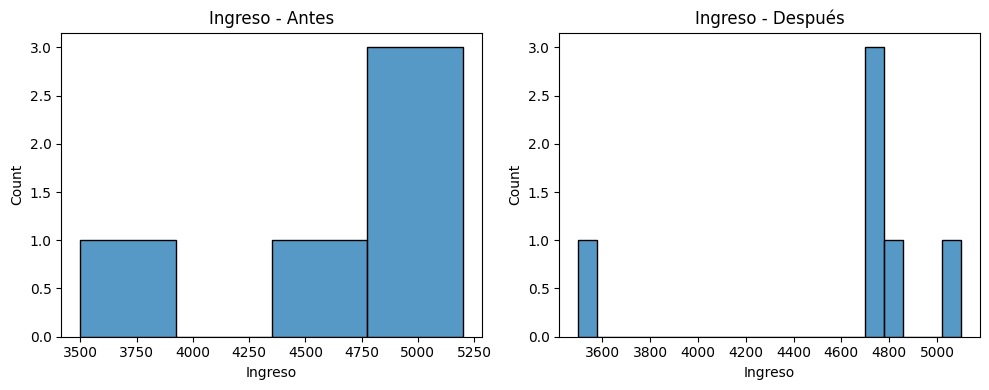

In [10]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_original['Ingreso'], kde=False)
plt.title("Ingreso - Antes")

plt.subplot(1,2,2)
sns.histplot(df['Ingreso'], kde=False)
plt.title("Ingreso - Después")

plt.tight_layout()
plt.show()

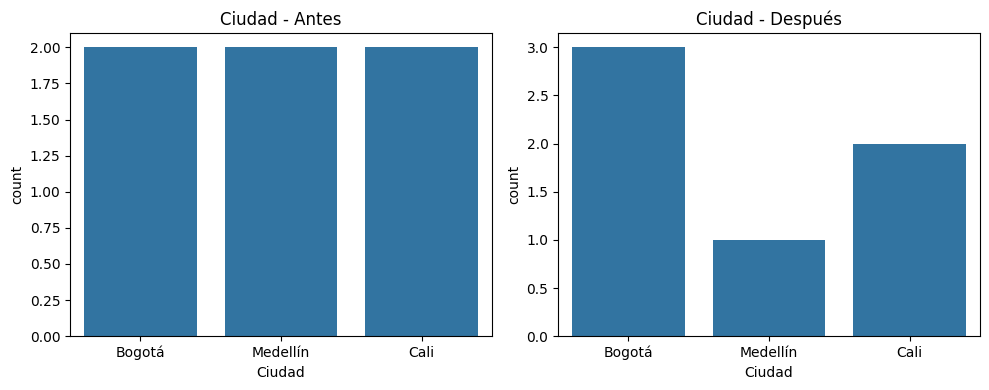

In [11]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.countplot(x=df_original['Ciudad'])
plt.title("Ciudad - Antes")

plt.subplot(1,2,2)
sns.countplot(x=df['Ciudad'])
plt.title("Ciudad - Después")

plt.tight_layout()
plt.show()

In [12]:
df[['Edad', 'Ingreso']].describe()

,Edad,Ingreso
count,6.000000,6.00000
mean,28.333333,4600.00000
std,3.651484,557.67374
min,25.000000,3500.00000
25%,25.833333,4712.50000
50%,28.333333,4750.00000
75%,28.333333,4787.50000
max,35.000000,5100.00000


## <span style="color:#2F749F;"><strong>Observaciones</strong></span>

- Edad antes: aparece un valor negativo (-5)
- Edad después: desaparece el valor negativo y la distribución se concentra entre 25–30


<strong>Datos estadísticos de la edad</strong></span>


Antes:
media = 21.8

Después:
media = 28.33

La limpieza eliminó un valor atípico e inválido, lo que provocó que la media de edad aumentara de 21.8 a 28.33.

Los valores faltantes en Ingreso y Ciudad fueron imputados conservando la estructura general del conjunto de datos.

## <span style="color:#2F749F;"><strong>Ejercicio 2. Limpieza de duplicados</strong></span>

1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'ID': [101, 102, 102, 103, 104, 104, 104],
        'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
        'Edad': [25, 30, 30, 29, 40, 40, 41],
        'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
        'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                        '2023-01-15', '2023-01-15', '2023-01-16']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, responde a las siguientes preguntas (utilizando python):
    - ¿Cuál es el total de registros originales?
    - ¿Cuáles y cuántos son los duplicados exactos?
    - ¿Cuáles y cuántos son los duplicados por varias columnas?
    - ¿Cuántos registros debes eliminar?
    - ¿Cuántos registros quedan después de la limpieza?

In [13]:
df = pd.DataFrame({
    'ID': [101, 102, 102, 103, 104, 104, 104],
    'Nombre': ['Ana', 'Luis', 'Luis', 'Marta', 'Carlos', 'Carlos', 'Carlos'],
    'Edad': [25, 30, 30, 29, 40, 40, 41],
    'Ciudad': ['Bogotá', 'Cali', 'Cali', 'Medellín', 'Cali', 'Cali', 'Cali'],
    'FechaRegistro': ['2023-01-01', '2023-01-05', '2023-01-05', '2023-01-10',
                    '2023-01-15', '2023-01-15', '2023-01-16']
})

In [14]:
#¿Cuál es el total de registros originales?
len(df)

7

In [15]:
#¿Cuáles y cuántos son los duplicados exactos?
duplicados_exactos = df[df.duplicated()]
duplicados_exactos
len(duplicados_exactos)

2

In [16]:
#¿Cuáles y cuántos son los duplicados por varias columnas?
duplicados_id = df[df.duplicated(subset=['ID'], keep=False)]
duplicados_id
len(duplicados_id)

5

In [17]:
#¿Cuántos registros debes eliminar?
df_sin_dup = df.drop_duplicates()
registros_eliminados = len(df) - len(df_sin_dup)
registros_eliminados

2

In [18]:
#¿Cuántos registros quedan después de la limpieza?
len(df_sin_dup)

5

## <span style="color:#2F749F;"><strong>Ejercicio 3. Corrección de errores tipográficos o de codificación</strong></span>


1. Crea el DataFrame base **df** ejecutando el siguiente código:
    ```python
    df = pd.DataFrame({
        'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
    })

2.  En el mismo notebook anterior, para el nuevo dataframe df, estandariza la variable ciudad utilizando python.

In [19]:
df = pd.DataFrame({
    'Ciudad': ['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota', 'BogoTa', 'Cali', 'calí', 'medellín', 'medellin']
})

## <span style="color:#2F749F;"><strong>Exploración de valores.</strong></span>

In [20]:
df['Ciudad'].unique()

array(['bogota', 'Bogotá', 'BOGOTA', 'bogotá', 'bogata', 'Bógota',
       'BogoTa', 'Cali', 'calí', 'medellín', 'medellin'], dtype=object)

## <span style="color:#2F749F;"><strong>Estandarizar la variable.</strong></span>

In [21]:
#Pasar todo a minúsculas
df['Ciudad'] = df['Ciudad'].str.lower()

#Eliminar espacios en blanco
df['Ciudad'] = df['Ciudad'].str.strip()

#Corrección de errores ortográficos
df.loc[df['Ciudad'] == 'bogata', 'Ciudad'] = 'bogota'
df.loc[df['Ciudad'] == 'bogota', 'Ciudad'] = 'bogota'

#Eliminar tildes
df['Ciudad'] = df['Ciudad'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

In [22]:
df['Ciudad'].unique()

array(['bogota', 'cali', 'medellin'], dtype=object)

## <span style="color:#2F749F;"><strong>Ejercicio 4. Identificación de mecanismos de datos faltantes (MCAR, MAR, MNAR)</strong></span>
1. Se tiene una base de datos de estudiantes universitarios con las siguientes variables: , Edad, Género, Promedio académico, Ingreso familiar y Horas de estudio por semana. Sin embargo, hay valores faltantes en algunas variables.
2. En los siguientes escenarios, clasifica el tipo de dato faltante (MCAR, MAR o MNAR) y justifica tu respuesta en máximo 2 líneas.
   - **Escenario 1.**  Al analizar los datos, se observa que los valores faltantes en Ingreso familiar aparecen de forma completamente aleatoria, sin relación con ninguna otra variable (ni edad, ni género, ni promedio, etc.).
   - **Escenario 2.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 3.** Se detecta que los valores faltantes en Horas de estudio ocurren principalmente en estudiantes con promedios bajos.
   - **Escenario 4.** Se observa que los valores faltantes en Promedio académico aparecen con mayor frecuencia en estudiantes de cierto género.
   - **Escenario 5.** Algunos estudiantes con muy pocas horas de estudio no reportan esta variable porque consideran que el valor es “demasiado bajo” para registrarlo.

## <span style="color:#2F749F;"><strong>Respuestas</strong></span>
   - **Escenario 1.**  MCAR, porque los valores faltantes no dependen de nada, ni de otras variables ni del propio valor, son completamente al azar.
   - **Escenario 2.** MAR, porque los valores faltantes en horas de estudio dependen del promedio académico.
   - **Escenario 3.** Se repite el escenario 2.
   - **Escenario 4.** MAR, porque los valores faltantes en promedio académico dependen del género, lo que indica un patrón no aleatorio.
   - **Escenario 5.** MNAR, los valores faltantes dependen del propio valor, es decir, no registrar las horas de estudio porque el propio valor es considerado como muy bajo, lo que implica un mecanismo no aleatorio.

## <span style="color:#2F749F;"><strong>Ejercicio 5. Imputación con KNN y regresión</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Edad': np.random.randint(18, 60, n),
            'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
            'Horas_estudio': np.random.randint(0, 40, n),
            'Ingreso_familiar': np.random.randint(800000, 8000000, n),
            'Semestres_cursados': np.random.randint(1, 10, n)
        })

        # Introducción de valores faltantes con distintos patrones
        df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
        df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
        df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

2. Al analizar el dataframe `df`:
   - ¿Qué variables tienen mayor proporción de datos faltantes?
   - ¿Observas algún patrón estructurado o parecen aleatorios?

3. Realiza la imputación de valores faltantes utilizando KNN y regresión
4. Analiza si se preserva la naturaleza de los datos con cada una de las técnicas de imputación (KNN y regresión)

In [23]:
np.random.seed(42)

n = 30

df = pd.DataFrame({
    'Edad': np.random.randint(18, 60, n),
    'Promedio': np.round(np.random.uniform(2.0, 5.0, n), 2),
    'Horas_estudio': np.random.randint(0, 40, n),
    'Ingreso_familiar': np.random.randint(800000, 8000000, n),
    'Semestres_cursados': np.random.randint(1, 10, n)
})

# Valores faltantes
df.loc[[2, 5, 8, 15], 'Promedio'] = np.nan
df.loc[[1, 7, 10, 18], 'Horas_estudio'] = np.nan
df.loc[[3, 6, 14], 'Ingreso_familiar'] = np.nan

In [24]:
# df = original con NaN
# df_knn = imputado con KNN
# df_reg = imputado con regresión

# Copia del original SOLO con filas completas (referencia “real”)
df_complete = df.dropna().copy()

cols = ['Promedio', 'Horas_estudio', 'Ingreso_familiar']

## <span style="color:#2F749F;"><strong>Análisis del dataframe</strong></span>

In [25]:
#¿Qué variables tienen mayor proporción de datos faltantes?
(df.isnull().sum() / len(df)) * 100

,0
Edad,0.000000
Promedio,13.333333
Horas_estudio,13.333333
Ingreso_familiar,10.000000
Semestres_cursados,0.000000


## <span style="color:#2F749F;"><strong>Respuestas</strong></span>

La mayor proporción la presentan Promedio y Horas_estudio.

No veo un patrón claro al momento de ingresar manualmente los valores faltantes, por lo que estos son aleatorios (MCAR). Además, no se observa dependencia con otras variables.

## <span style="color:#2F749F;"><strong>Imputación con KNN</strong></span>

In [26]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=3)

df_knn = pd.DataFrame(
    knn_imputer.fit_transform(df),
    columns=df.columns
)

## <span style="color:#2F749F;"><strong>Imputación con Regresión</strong></span>

In [27]:
#eliminar NaN en variables predictoras

# Copia del dataframe original
df_reg = df.copy()

# Imputación
imputer = SimpleImputer(strategy='mean')

df_temp = pd.DataFrame(
    imputer.fit_transform(df_reg),
    columns=df_reg.columns
)

In [28]:
#Promedio-----------------------------------------------------------
# Máscara de valores faltantes
mask = df['Promedio'].isnull()

# Variables predictoras
X = df_temp.drop(columns=['Promedio'])
y = df_temp['Promedio']

# Modelo
model = LinearRegression()
model.fit(X[~mask], y[~mask])

# Predicción
df_reg.loc[mask, 'Promedio'] = model.predict(X[mask])


#Horas_estudio--------------------------------------------------------
# Máscara de valores faltantes
mask = df['Horas_estudio'].isnull()

# Variables predictoras
X = df_temp.drop(columns=['Horas_estudio'])
y = df_temp['Horas_estudio']

# Modelo
model = LinearRegression()
model.fit(X[~mask], y[~mask])

# Predicción
df_reg.loc[mask, 'Horas_estudio'] = model.predict(X[mask])


#Ingreso_familiar----------------------------------------------------
# Máscara de valores faltantes
mask = df['Ingreso_familiar'].isnull()

# Variables predictoras
X = df_temp.drop(columns=['Ingreso_familiar'])
y = df_temp['Ingreso_familiar']

# Modelo
model = LinearRegression()
model.fit(X[~mask], y[~mask])

# Predicción
df_reg.loc[mask, 'Ingreso_familiar'] = model.predict(X[mask])

In [29]:
df_reg.isnull().sum()

,0
Edad,0
Promedio,0
Horas_estudio,0
Ingreso_familiar,0
Semestres_cursados,0


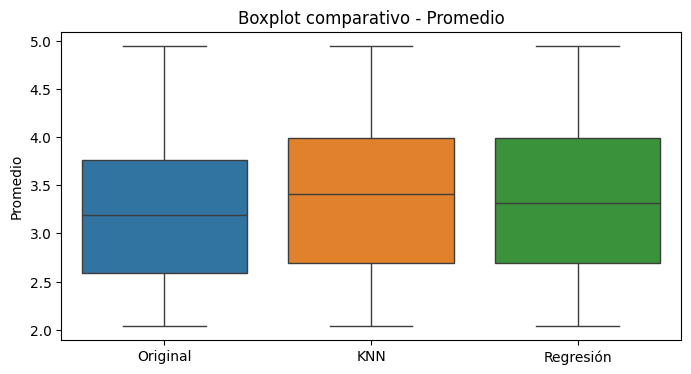

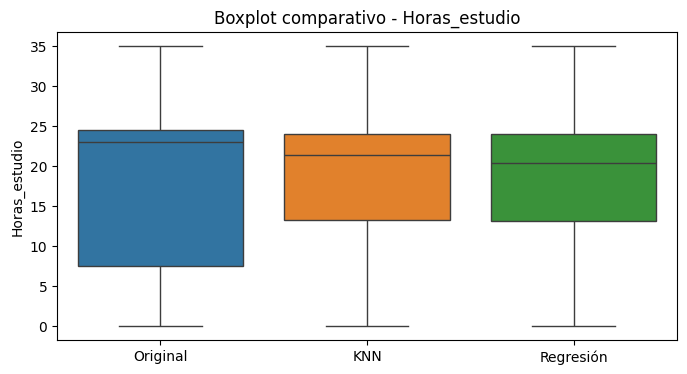

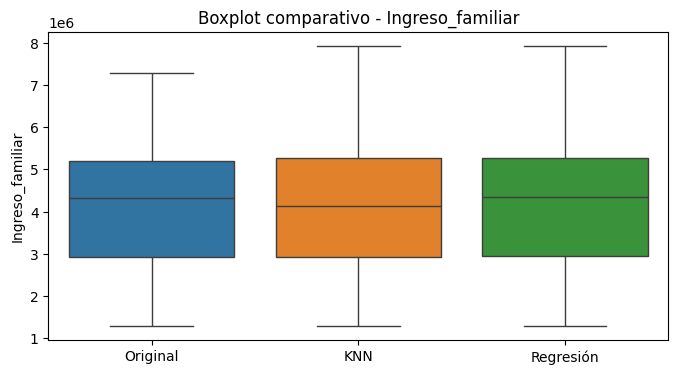

In [30]:
for col in cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(data=pd.DataFrame({
        'Original': df_complete[col],
        'KNN': df_knn[col],
        'Regresión': df_reg[col]
    }))
    plt.title(f"Boxplot comparativo - {col}")
    plt.ylabel(col)
    plt.show()

In [31]:
summary = pd.concat({
    'Original': df_complete[cols].describe(),
    'KNN': df_knn[cols].describe(),
    'Regresión': df_reg[cols].describe()
}, axis=1)

summary

Original                                       KNN                \
        Promedio Horas_estudio Ingreso_familiar   Promedio Horas_estudio   
count  19.000000     19.000000     1.900000e+01  30.000000     30.000000   
mean    3.249474     18.263158     4.252257e+06   3.389778     19.111111   
std     0.847948     11.498029     1.605142e+06   0.836486      9.665808   
min     2.040000      0.000000     1.291234e+06   2.040000      0.000000   
25%     2.585000      7.500000     2.915754e+06   2.692500     13.250000   
50%     3.190000     23.000000     4.321441e+06   3.411667     21.333333   
75%     3.765000     24.500000     5.193346e+06   3.987500     24.000000   
max     4.950000     35.000000     7.293120e+06   4.950000     35.000000   

                        Regresión                                 
      Ingreso_familiar   Promedio Horas_estudio Ingreso_familiar  
count     3.000000e+01  30.000000     30.000000     3.000000e+01  
mean      4.217002e+06   3.375325     18.688244     4.336660e+06  
std       1.704828e+06   0.837389      9.721489     1.659491e+06  
min       1.291234e+06   2.040000      0.000000     1.291234e+06  
25%       2.912786e+06   2.692500     13.054861     2.949214e+06  
50%       4.129085e+06   3.315000     20.376281     4.350373e+06  
75%       5.264558e+06   3.987500     24.000000     5.264558e+06  
max       7.930144e+06   4.950000     35.000000     7.930144e+06

In [32]:
def comparar_imputacion(col):
    mask = df[col].isnull()

    comp = pd.DataFrame({
        'KNN': df_knn.loc[mask, col],
        'Regresión': df_reg.loc[mask, col]
    })

    print(f"\n--- {col} ---")
    print(comp)
    print("\nResumen:")
    print(comp.describe())

for c in cols:
    comparar_imputacion(c)


--- Promedio ---
         KNN  Regresión
2   3.473333   3.381359
5   3.473333   3.516055
8   3.473333   3.142591
15  3.473333   3.419754

Resumen:
            KNN  Regresión
count  4.000000   4.000000
mean   3.473333   3.364940
std    0.000000   0.158691
min    3.473333   3.142591
25%    3.473333   3.321667
50%    3.473333   3.400557
75%    3.473333   3.443829
max    3.473333   3.516055

--- Horas_estudio ---
          KNN  Regresión
1   21.333333  20.752561
7   21.333333  22.412921
10  21.333333  13.219445
18  21.333333  16.262383

Resumen:
             KNN  Regresión
count   4.000000   4.000000
mean   21.333333  18.161828
std     0.000000   4.195979
min    21.333333  13.219445
25%    21.333333  15.501648
50%    21.333333  18.507472
75%    21.333333  21.167651
max    21.333333  22.412921

--- Ingreso_familiar ---
             KNN     Regresión
3   2.955269e+06  4.358818e+06
6   3.609593e+06  4.341928e+06
14  2.778672e+06  4.232508e+06

Resumen:
                KNN     Regresión
count

## <span style="color:#2F749F;"><strong>Análisis</strong></span>

Para Promedio, la regresión conserva mejor la naturaleza de los datos, mientras que KNN introduce un valor constante que reduce la variabilidad, por este motivo tenemos una desviación estandar de cero.

En Horas_estudio, KNN vuelve a generar un valor fijo (std = 0), mientras que la regresión mantiene una dispersión coherente con el comportamiento del conjunto original.

Para Ingreso_familiar, la regresión reduce excesivamente la dispersión, mientras que KNN conserva mejor la variabilidad de los datos.

## <span style="color:#2F749F;"><strong>Ejercicio 6. Imputación con LOCF y NOCB</strong></span>

1. Crea el DataFrame base ejecutando el siguiente código:

    ```python
        import pandas as pd
        import numpy as np

        np.random.seed(42)

        n = 30

        df = pd.DataFrame({
            'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
            'Ventas': np.round(np.random.uniform(100, 500, n), 2),
            'Inventario': np.random.randint(10, 100, n),
            'Clientes': np.random.randint(1, 50, n)
        })

        # Introducción de valores faltantes
        df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
        df.loc[[7, 8, 20], 'Inventario'] = np.nan
        df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
        df = df.sort_values('Fecha').reset_index(drop=True)

2. Al analizar el DataFrame `df`:
   - ¿Qué variables presentan datos faltantes consecutivos?
   - ¿Por qué este tipo de patrón es relevante en series temporales?
   - ¿Qué implicaciones tiene el orden de los datos para este tipo de imputación?
3. Realiza la imputación de valores faltantes utilizando LOCF y NOCB
4. ¿Cuál método consideras más apropiado para este caso y por qué?

In [33]:
    np.random.seed(42)

    n = 30

    df = pd.DataFrame({
        'Fecha': pd.date_range(start='2023-01-01', periods=n, freq='D'),
        'Ventas': np.round(np.random.uniform(100, 500, n), 2),
        'Inventario': np.random.randint(10, 100, n),
        'Clientes': np.random.randint(1, 50, n)
    })

    # Introducción de valores faltantes
    df.loc[[3, 4, 5, 12, 13], 'Ventas'] = np.nan
    df.loc[[7, 8, 20], 'Inventario'] = np.nan
    df.loc[[1, 2, 18, 19], 'Clientes'] = np.nan
    df = df.sort_values('Fecha').reset_index(drop=True)

## <span style="color:#2F749F;"><strong>Análisis del Dataframe</strong></span>

In [34]:
def detectar_nan_consecutivos(df, col):
    mask = df[col].isna()

    grupos = (mask != mask.shift()).cumsum()

    resultado = df[mask].groupby(grupos[mask]).agg({
        col: 'size'
    }).rename(columns={col: 'longitud'})

    return resultado

for col in ['Ventas', 'Inventario', 'Clientes']:
    print(f"\n🔹 {col}")
    print(detectar_nan_consecutivos(df, col))


🔹 Ventas
        longitud
Ventas          
2              3
4              2

🔹 Inventario
            longitud
Inventario          
2                  2
4                  1

🔹 Clientes
          longitud
Clientes          
2                2
4                2


In [35]:
for col in df.columns:
    if df[col].isna().any():
        consecutivos = (df[col].isna() & df[col].isna().shift()).any()
        print(f"{col}: {'Tiene consecutivos' if consecutivos else 'No tiene consecutivos'}")

Ventas: Tiene consecutivos
Inventario: Tiene consecutivos
Clientes: Tiene consecutivos


El análisis del DataFrame evidencia que las variables Ventas, Inventario y Clientes presentan valores faltantes consecutivos. Este patrón es relevante en series temporales porque indica periodos sin observación, lo que puede afectar la continuidad y distorsionar tendencias. Un desorden en las fechas generaría imputaciones incorrectas al utilizar valores previos o futuros que no corresponden.

## <span style="color:#2F749F;"><strong>Imputación con LOCF</strong></span>

In [36]:
df_locf = df.copy()

df_locf['Ventas'] = df_locf['Ventas'].ffill()
df_locf['Inventario'] = df_locf['Inventario'].ffill()
df_locf['Clientes'] = df_locf['Clientes'].ffill()

## <span style="color:#2F749F;"><strong>Imputación con NOCB</strong></span>

In [37]:
df_nocb = df.copy()

df_nocb['Ventas'] = df_nocb['Ventas'].bfill()
df_nocb['Inventario'] = df_nocb['Inventario'].bfill()
df_nocb['Clientes'] = df_nocb['Clientes'].bfill()

## <span style="color:#2F749F;"><strong>LOCF vs NOCB</strong></span>

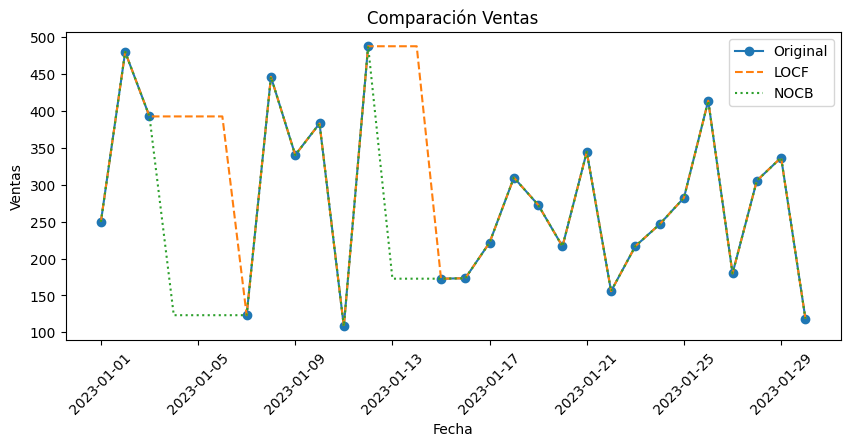

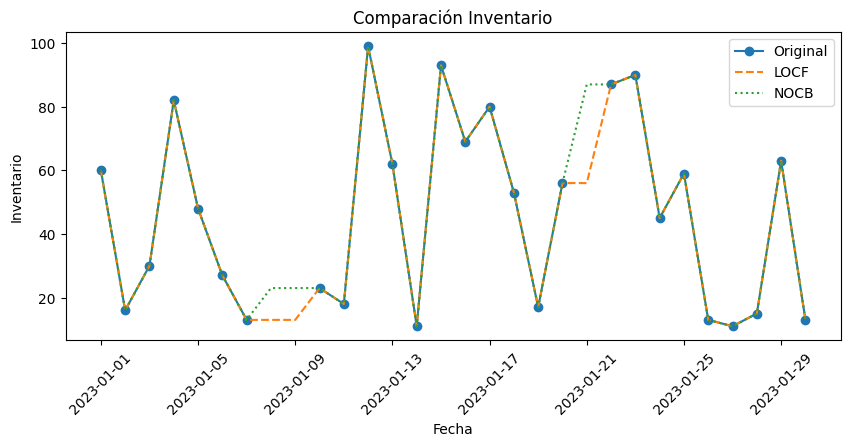

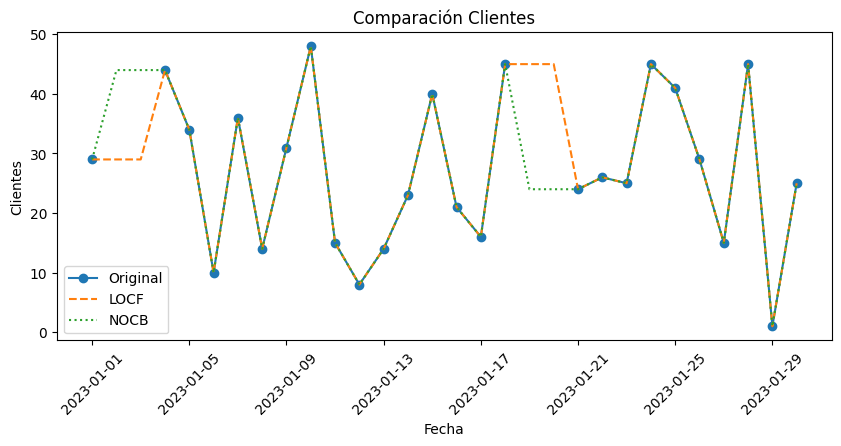

In [38]:
import matplotlib.pyplot as plt

cols = ['Ventas','Inventario','Clientes']

for col in cols:
    plt.figure(figsize=(10,4))
    plt.plot(df['Fecha'], df[col], 'o-', label='Original')
    plt.plot(df_locf['Fecha'], df_locf[col], '--', label='LOCF')
    plt.plot(df_nocb['Fecha'], df_nocb[col], ':', label='NOCB')
    plt.title(f'Comparación {col}')
    plt.xlabel('Fecha'); plt.ylabel(col)
    plt.legend(); plt.xticks(rotation=45)
    plt.show()

In [39]:
def suavidad(s):
    return np.nanstd(np.diff(s))

res_suavidad = pd.DataFrame({
    'LOCF': [suavidad(df_locf[c]) for c in cols],
    'NOCB': [suavidad(df_nocb[c]) for c in cols]
}, index=cols)

res_suavidad

,LOCF,NOCB
Ventas,163.894190,163.894190
Inventario,36.344533,36.344533
Clientes,18.591292,18.591292


In [40]:
def error_bloques(df_orig, df_imp, col):
    mask = df_orig[col].isna()
    grupos = (mask != mask.shift()).cumsum()
    errs = []
    for g, idx in df_orig[mask].groupby(grupos[mask]).groups.items():
        i0, i1 = min(idx), max(idx)
        left = df_orig[col].iloc[i0-1] if i0-1 >= 0 else np.nan
        right = df_orig[col].iloc[i1+1] if i1+1 < len(df_orig) else np.nan
        ref = np.nanmean([left, right])  # referencia local
        imp_vals = df_imp.loc[idx, col].values
        if not np.isnan(ref):
            errs.append(np.mean(np.abs(imp_vals - ref)))
    return np.mean(errs)

res_error = pd.DataFrame({
    'LOCF': [error_bloques(df, df_locf, c) for c in cols],
    'NOCB': [error_bloques(df, df_nocb, c) for c in cols]
}, index=cols)

res_error

,LOCF,NOCB
Ventas,146.20,146.20
Inventario,10.25,10.25
Clientes,9.00,9.00


## <span style="color:#2F749F;"><strong>Análisis</strong></span>

LOCF es más adecuado.

Las métricas de suavidad y error resultaron ser iguales, pero en las gráficas se observa que LOCF mantiene la continuidad temporal replicando el último valor observado, lo cual es coherente con la evolución natural de variables como ventas, inventario y clientes. Por el contrario, NOCB introduce valores futuros, generando cambios abruptos que no respetan la secuencia temporal real.

